<a href="https://colab.research.google.com/github/holaamigoo/Machine-Learning/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%967_Random_forest_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №7. Random forest**

## **Задание 1. Обучите классификатор Random Forest для решения задачи бинарной классификации: для каждого человека научиться предсказывать, выживет ли он при крушении Титаника.**



Ссылка на датасет: https://www.kaggle.com/c/titanic/data

### 1. Устанавливаем зависимости

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Импортируем датасет

In [2]:
!wget 'https://drive.google.com/uc?export=download&id=1cLiYMd5YSpfJn5ajneHtin55i79KU7sB' -O test.csv
!wget 'https://drive.google.com/uc?export=download&id=1oDzBtqrXFDnc4ABbAi5hy9UXXT5uVdbD' -O train.csv

--2026-04-15 12:22:16--  https://drive.google.com/uc?export=download&id=1cLiYMd5YSpfJn5ajneHtin55i79KU7sB
Resolving drive.google.com (drive.google.com)... 172.253.117.100, 172.253.117.102, 172.253.117.138, ...
Connecting to drive.google.com (drive.google.com)|172.253.117.100|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1cLiYMd5YSpfJn5ajneHtin55i79KU7sB&export=download [following]
--2026-04-15 12:22:16--  https://drive.usercontent.google.com/download?id=1cLiYMd5YSpfJn5ajneHtin55i79KU7sB&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 74.125.20.132, 2607:f8b0:400e:c09::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|74.125.20.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 28629 (28K) [application/octet-stream]
Saving to: ‘test.csv’

test.csv            100%[===================>]  27.96K  --.-KB/s    in 

### 3. Производим разведовательный анализ данных


Получим представление о данных в датасете:

In [3]:
df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
# Ваш код
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### 4. Сформируем обучающую и тестовую выборки:


In [6]:
# поделим train.csv, игнорим test.csv ибо он предназначен для того датасета из конкурса (не имеет ответов, из-за чего невозможно оценить работу)
from sklearn.model_selection import train_test_split

# 1. Обработка пропусков ПЕРЕД кодированием
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Age'] = df['Age'].fillna(df['Age'].mean())                   # исправлена критическая ошибка

# 2. Удаление колонок (современный синтаксис pandas)
df = df.drop(columns=['Cabin', "Name", "Ticket", "PassengerId"])

# 3. One-Hot Encoding
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

X = df.drop(columns=['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

print(X_train.shape, X_test.shape)

(596, 8) (295, 8)


### 5. Feature Engineering

Поработаем с признаками, выделим важные, изменим форму их представления (при надобности)

In [7]:
# Удалим колонки с именем/номером билета, т.к. эти данные наименее полезны

print(X_train.shape)
display(X_train.info()) #проверка, нет ли пустых объектов
X_train.head()

(596, 8)
<class 'pandas.core.frame.DataFrame'>
Index: 596 entries, 6 to 102
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      596 non-null    int64  
 1   Age         596 non-null    float64
 2   SibSp       596 non-null    int64  
 3   Parch       596 non-null    int64  
 4   Fare        596 non-null    float64
 5   Sex_male    596 non-null    bool   
 6   Embarked_Q  596 non-null    bool   
 7   Embarked_S  596 non-null    bool   
dtypes: bool(3), float64(2), int64(3)
memory usage: 29.7 KB


None

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
6,1,54.000000,0,0,51.8625,True,False,True
718,3,29.699118,0,0,15.5000,True,True,False
685,2,25.000000,1,2,41.5792,True,False,False
73,3,26.000000,1,0,14.4542,True,False,False
882,3,22.000000,0,0,10.5167,False,False,True


### 6. Построение базовой модели:

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
model.feature_importances_

array([0.13428827, 0.11109818, 0.05220281, 0.04114534, 0.19864338,
       0.41542796, 0.01421373, 0.03298033])

In [ ]:
feature_scores = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

feature_scores

,0
Sex_male,0.415428
Fare,0.198643
Pclass,0.134288
Age,0.111098
SibSp,0.052203
Parch,0.041145
Embarked_S,0.032980
Embarked_Q,0.014214


### 7. Оценка точности модели:

#### 7.1. Напишите функцию, принимающую на вход аргументы y_pred, y_test и выполняющую визуализацию матрицы ошибок и отчета классификации

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report


def visualize_matrix(y_pred, y_test):
  cm = confusion_matrix(y_test, y_pred)
  plt.figure(figsize=(8, 6))
  sns.heatmap(cm, annot=True, fmt=".0f", cmap='Blues')
  plt.title('Матрица ошибок')
  plt.xlabel('Предсказанные')
  plt.ylabel('Реальные')
  plt.show()
  print(classification_report(y_test, y_pred))

#### 7.2. Оцените точность модели:

(295,) (295,)


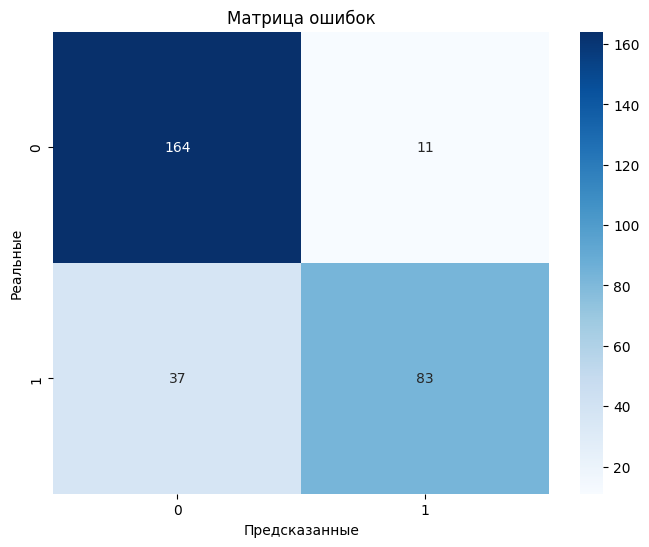

              precision    recall  f1-score   support

           0       0.82      0.94      0.87       175
           1       0.88      0.69      0.78       120

    accuracy                           0.84       295
   macro avg       0.85      0.81      0.82       295
weighted avg       0.84      0.84      0.83       295



In [ ]:
print(y_pred.shape, y_test.shape)
visualize_matrix(y_pred, y_test)

### 8. Тюнинг гиперпараметров модели:

#### RandomSearchCV

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
#время выполнения - ~4 мин.

max_depth = [int(i) for i in np.linspace(start=1, stop=80, num=8)]
max_depth.append(None)
param_grid = {
    'n_estimators': [int(x) for x in np.linspace(start=10, stop=300, num=8)],
    'max_leaf_nodes': [int(i) for i in np.linspace(start=2, stop=50, num=8)],
    'max_depth': max_depth
}
rf_rcv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=100,
    scoring='accuracy',
    cv=5,
    verbose=0,
    random_state=42,
    n_jobs=-1
)

rf_rcv.fit(X_train, y_train)

rcv_best_params = rf_rcv.best_params_

print(f"Лучшие параметры: {rcv_best_params}")

Лучшие параметры: {'n_estimators': 10, 'max_leaf_nodes': 43, 'max_depth': 23}


In [ ]:
# Создаем новый классификатор случайного леса с оптимальными гиперпараметрами
rf_rcv = RandomForestClassifier(**rcv_best_params)

# Обучаем модель с оптимальными гиперпараметрами на обучающих данных
rf_rcv.fit(X_train, y_train)

# Предсказываем классы для тестовых данных
y_pred = rf_rcv.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

# Выводим оценку точности модели на тестовых данных
print('Оценка точности модели при подборе параметров с помощью RandomizedSearchCV: {0:0.4f}'.format(accuracy_score(y_test, y_pred)))

Оценка точности модели при подборе параметров с помощью RandomizedSearchCV: 0.7932


#### GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

if rcv_best_params['n_estimators'] >= 4:
  n_estimators = [int(x) for x in range(rcv_best_params['n_estimators']-3, rcv_best_params['n_estimators']+4)]
else:
  n_estimators = [int(x) for x in range(1, 8)]
if rcv_best_params['max_leaf_nodes'] >= 5:
  max_leaf_nodes = [int(i) for i in range(rcv_best_params['max_leaf_nodes']-3, rcv_best_params['max_leaf_nodes']+4)]
else:
  max_leaf_nodes = [int(i) for i in range(2, 9)]
if rcv_best_params['max_depth'] >= 4:
  max_depth = [int(x) for x in range(rcv_best_params['max_depth']-3, rcv_best_params['max_depth']+4)]
else:
  max_depth = [int(x) for x in range(1, 8)]
max_depth.append(None)

# Определяем список значений для параметра max_leaf_nodes (максимальное количество листьев)
max_leaf_nodes = [int(i) for i in range(1, 100)]

# Создаем словарь с параметрами для перебора в GridSearchCV
params_grid = {
    'n_estimators': n_estimators,
    'max_depth': max_depth,
    'max_leaf_nodes': max_leaf_nodes,
}


# Настраиваем GridSearchCV для поиска наилучших гиперпараметров
rf_cv = GridSearchCV(
    estimator=model,        # модель для настройки
    param_grid=params_grid,  # словарь с параметрами для перебора
    scoring="accuracy",      # метрика для оценки качества моделей
    cv=5,                    # количество фолдов для кросс-валидации
    verbose=1,               # уровень детализации вывода
    n_jobs=-1                # использование всех доступных ядер процессора
)

# Обучаем модель GridSearchCV на обучающих данных
rf_cv.fit(X_train, y_train)

# Получаем лучшие найденные параметры
best_params = rf_cv.best_params_
print(f"Лучшие параметры: {best_params}")

Fitting 5 folds for each of 5544 candidates, totalling 27720 fits
Лучшие параметры: {'max_depth': 20, 'max_leaf_nodes': 41, 'n_estimators': 11}


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
280 fits failed out of a total of 27720.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
280 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/ut

In [ ]:
# Обучаем окончательную модель с лучшими параметрами на обучающих данных
rf_cv = RandomForestClassifier(**best_params)
rf_cv.fit(X_train, y_train)

# Предсказываем классы для тестовых данных
y_pred = rf_cv.predict(X_test)

# Выводим оценку точности модели на тестовых данных
print('Оценка точности модели при подборе параметров с помощью GridSearchCV: {0:0.4f}'.format(accuracy_score(y_test, y_pred)))

Оценка точности модели при подборе параметров с помощью GridSearchCV: 0.8034


In [ ]:
# Модель с GridSearchCV обучилась немного лучше, чем RandomSearchCV, но модель без подбора параметров оказалась самой точной - 84% точности

### 9. Комплексная оценка точности лучшей модели:

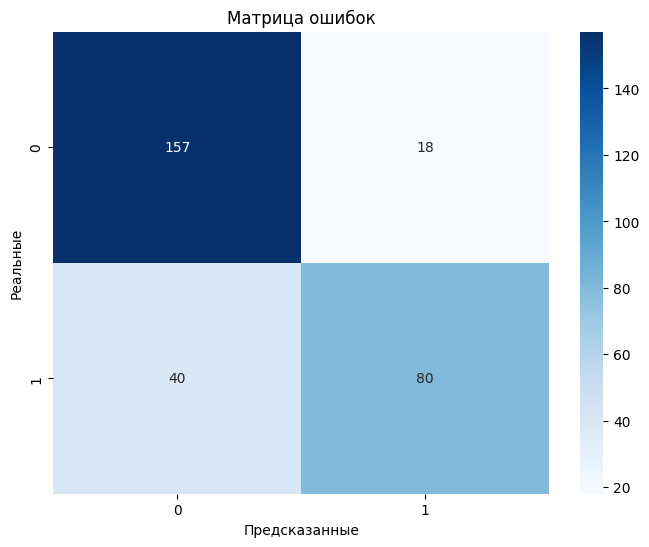

              precision    recall  f1-score   support

           0       0.80      0.90      0.84       175
           1       0.82      0.67      0.73       120

    accuracy                           0.80       295
   macro avg       0.81      0.78      0.79       295
weighted avg       0.80      0.80      0.80       295



In [ ]:
visualize_matrix(y_pred, y_test)

## **Задание 2. Решите задачу из предыдущего пункта используя другие, ранее пройденные классификаторы. Сравните их точность предсказания с Random Forest**

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler


models = {'lr': LogisticRegression(random_state=1),
          'knn': KNeighborsClassifier(),
          'dt': DecisionTreeClassifier(random_state=1)}


# Масштабирование для KNN
# KNeighborsClassifier чувствителен к масштабу признаков
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
# Передавайте X_train_s / X_test_s в model.fit() и model.predict()

for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)

    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name}:")
    print(f"  Accuracy:  {acc:.4f}")


lr:
  Accuracy:  0.8169

knn:
  Accuracy:  0.7966

dt:
  Accuracy:  0.7593


## **Задание 2.1. Реализуйте функцию, для взаимодействия с обученной Вами моделью**



* Функция должна принимать на вход обученную модель классификатора;

* После вызова функции, у пользователя через консоль запрашиваются значения признаков. При запросе значений нужно вывести пояснения о типе и диапазоне возможных значений. Также реализуйте обработку исключений;

* После ввода значений для всех признаков в консоль, выводится результат работы классификатора.

In [10]:
import pandas as pd

def predictor(model):
    print("Введите параметры пассажира Титаника:")
    data = {}

    # (prompt, тип, min, max)
    for col, cfg in {
        'Pclass': ("Класс каюты (целое, 1-3): ", int, 1, 3),
        'Age':    ("Возраст (вещественное, 0-120): ", float, 0, 120),
        'SibSp':  ("Родственников/супругов (целое, 0-10): ", int, 0, 10),
        'Parch':  ("Родителей/детей (целое, 0-10): ", int, 0, 10),
        'Fare':   ("Стоимость билета (вещественное, >0): ", float, 0, 600)
    }.items():
        while True:
            try:
                val = cfg[1](input(cfg[0]))
                if cfg[2] <= val <= cfg[3]:
                    data[col] = val
                    break
                print("Значение вне допустимого диапазона.")
            except ValueError:
                print("Ошибка формата. Ожидается число.")

    # Категориальные признаки с маппингом в dummy-переменные
    while True:
        s = input("Пол (строка: male/female): ").strip().lower()
        if s in ('male', 'female'):
            data['Sex_male'] = (s == 'male')
            break
        print("Введите 'male' или 'female'.")

    while True:
        p = input("Порт (строка: S/C/Q, где C — базовый): ").strip().upper()
        if p in ('S', 'C', 'Q'):
            data['Embarked_Q'] = (p == 'Q')
            data['Embarked_S'] = (p == 'S')
            break
        print("Введите 'S', 'C' или 'Q'.")

    # Предсказание
    pred = model.predict(pd.DataFrame([data]))[0]
    print(f"\nРезультат: {'Выживет ✅' if pred else 'Не выживет ❌'}")

predictor(model)

# Класс пассажира (1-3): 1
# Возраст (0-inf): 50
# Количество родных партнеров/братьев/сестер на борту (0-inf): 1
# Кол-во родных родителей/детей на борту (0-inf): 1
# Плата за проезд (0-inf): 10
# Пол (male/female): male
# Из какого города отправились (S/C/Q): S

Введите параметры пассажира Титаника:
Класс каюты (целое, 1-3): 2
Возраст (вещественное, 0-120): 30
Родственников/супругов (целое, 0-10): 3
Родителей/детей (целое, 0-10): 1
Стоимость билета (вещественное, >0): 500
Пол (строка: male/female): male
Порт (строка: S/C/Q, где C — базовый): S

Результат: Не выживет ❌


## **Задание 3. Решите задачу регрессии, используя [RandomForestRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html).**

**ОБЯЗАТЕЛЬНО ОСУЩЕСТВИТЕ ПОДБОР ОПТИМАЛЬНЫХ ПАРАМЕТРОВ, ИСПОЛЬЗУЯ RandomSearchCV и GridSearchCV**



* Для выполнения данного задания можете использовать **любой датасет**



Ссылка на один из сайтов-источников датасетов: https://www.kaggle.com/datasets?tags=14203-Regression

In [29]:
import kagglehub
import pandas as pd

kagglehub.dataset_download("mohankrishnathalla/sleep-health-and-daily-performance-dataset")
df = pd.read_csv('/kaggle/input/sleep-health-and-daily-performance-dataset/sleep_health_dataset.csv') # если вывел ошибку, запустить еще раз
df = df.head(10000)

Using Colab cache for faster access to the 'sleep-health-and-daily-performance-dataset' dataset.


In [30]:
display(df.head())
display(df.info())
df.describe()

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_id                    10000 non-null  int64  
 1   age                          10000 non-null  int64  
 2   gender                       10000 non-null  object 
 3   occupation                   10000 non-null  object 
 4   bmi                          10000 non-null  float64
 5   country                      10000 non-null  object 
 6   sleep_duration_hrs           10000 non-null  float64
 7   sleep_quality_score          10000 non-null  float64
 8   rem_percentage               10000 non-null  float64
 9   deep_sleep_percentage        10000 non-null  float64
 10  sleep_latency_mins           10000 non-null  int64  
 11  wake_episodes_per_night      10000 non-null  int64  
 12  caffeine_mg_before_bed       10000 non-null  int64  
 13  alcohol_units_bef

None

,person_id,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,...,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,cognitive_performance_score,felt_rested
count,10000.00000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,34.50170,26.247050,6.412116,4.847570,20.220100,20.293620,19.907600,3.357000,38.867000,...,14.749000,5.771250,7.17126,66.502200,0.557900,0.082300,20.543580,1.212015,58.934170,0.39150
std,2886.89568,10.97685,4.464494,1.283687,1.515894,3.423622,4.246689,7.605804,1.932078,69.651069,...,21.329583,1.602169,3.44792,7.127866,0.496661,0.274835,2.906818,0.786791,22.346157,0.48811
min,1.00000,18.00000,16.000000,3.000000,1.000000,10.000000,5.000000,1.000000,0.000000,0.000000,...,0.000000,1.000000,0.00000,45.000000,0.000000,0.000000,15.000000,-1.000000,0.000000,0.00000
25%,2500.75000,26.00000,23.200000,5.527500,3.800000,18.000000,17.400000,14.000000,2.000000,0.000000,...,0.000000,4.800000,4.80000,62.000000,0.000000,0.000000,18.400000,0.670000,44.000000,0.00000
50%,5000.50000,33.00000,26.200000,6.340000,4.900000,20.300000,20.400000,20.000000,3.000000,0.000000,...,0.000000,5.900000,7.40000,66.000000,1.000000,0.000000,20.500000,1.210000,59.800000,0.00000
75%,7500.25000,42.00000,29.300000,7.270000,5.900000,22.600000,23.200000,25.000000,5.000000,80.000000,...,30.000000,6.900000,9.70000,71.000000,1.000000,0.000000,22.600000,1.750000,75.400000,1.00000
max,10000.00000,69.00000,44.400000,10.500000,9.600000,30.000000,30.000000,55.000000,8.000000,400.000000,...,108.000000,10.000000,17.30000,93.000000,1.000000,1.000000,28.000000,3.000000,100.000000,1.00000


In [31]:
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from scipy.stats import randint

# 1. Целевая переменная и подготовка
TARGET = 'cognitive_performance_score'
# Убираем ID, country (высокая кардинальность) и признаки-потенциальные "утечки"
DROP_COLS = ['person_id', 'country', 'felt_rested', 'sleep_disorder_risk']

X = df.drop(columns=[TARGET] + DROP_COLS, errors='ignore')
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

cat_cols = X.select_dtypes(include=['object', 'category']).columns
num_cols = X.select_dtypes(include='number').columns

# 2. Пайплайн (масштабирование не нужно для RF)
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols),
    ('num', 'passthrough', num_cols)
])

pipeline = Pipeline([
    ('prep', preprocessor),
    ('rf', RandomForestRegressor(random_state=42, n_jobs=-1))
])

# 3. RandomizedSearchCV
param_dist = {
    'rf__n_estimators': randint(50, 200),
    'rf__max_depth': randint(3, 12),
    'rf__min_samples_split': randint(5, 20),
    'rf__min_samples_leaf': randint(2, 8),
    'rf__max_features': ['sqrt', 'log2', None]
}

rs = RandomizedSearchCV(pipeline, param_dist, n_iter=25, cv=3,
                        scoring='neg_mean_absolute_error', random_state=42, n_jobs=-1)
rs.fit(X_train, y_train)
print(f"RandomSearch | Best MAE: {-rs.best_score_:.4f}")

# 4. GridSearchCV (точечная настройка)
bp = rs.best_params_
param_grid = {
    'rf__n_estimators': [max(50, bp['rf__n_estimators']-50), bp['rf__n_estimators'], bp['rf__n_estimators']+50],
    'rf__max_depth': [max(2, bp['rf__max_depth']-2), bp['rf__max_depth'], bp['rf__max_depth']+2],
    'rf__min_samples_split': [max(2, bp['rf__min_samples_split']-1), bp['rf__min_samples_split'], bp['rf__min_samples_split']+1]
}

gs = GridSearchCV(pipeline, param_grid, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
gs.fit(X_train, y_train)
print(f"GridSearch   | Best MAE: {-gs.best_score_:.4f}")

# 5. Итоговые метрики
y_pred = gs.best_estimator_.predict(X_test)
print(f"\nИтог | R²: {r2_score(y_test, y_pred):.4f} | MAE: {mean_absolute_error(y_test, y_pred):.4f}")

RandomSearch | Best MAE: 5.7189
GridSearch   | Best MAE: 5.6561

Итог | R²: 0.9006 | MAE: 5.5970


In [32]:
gs.best_params_

{'rf__max_depth': 12, 'rf__min_samples_split': 5, 'rf__n_estimators': 222}

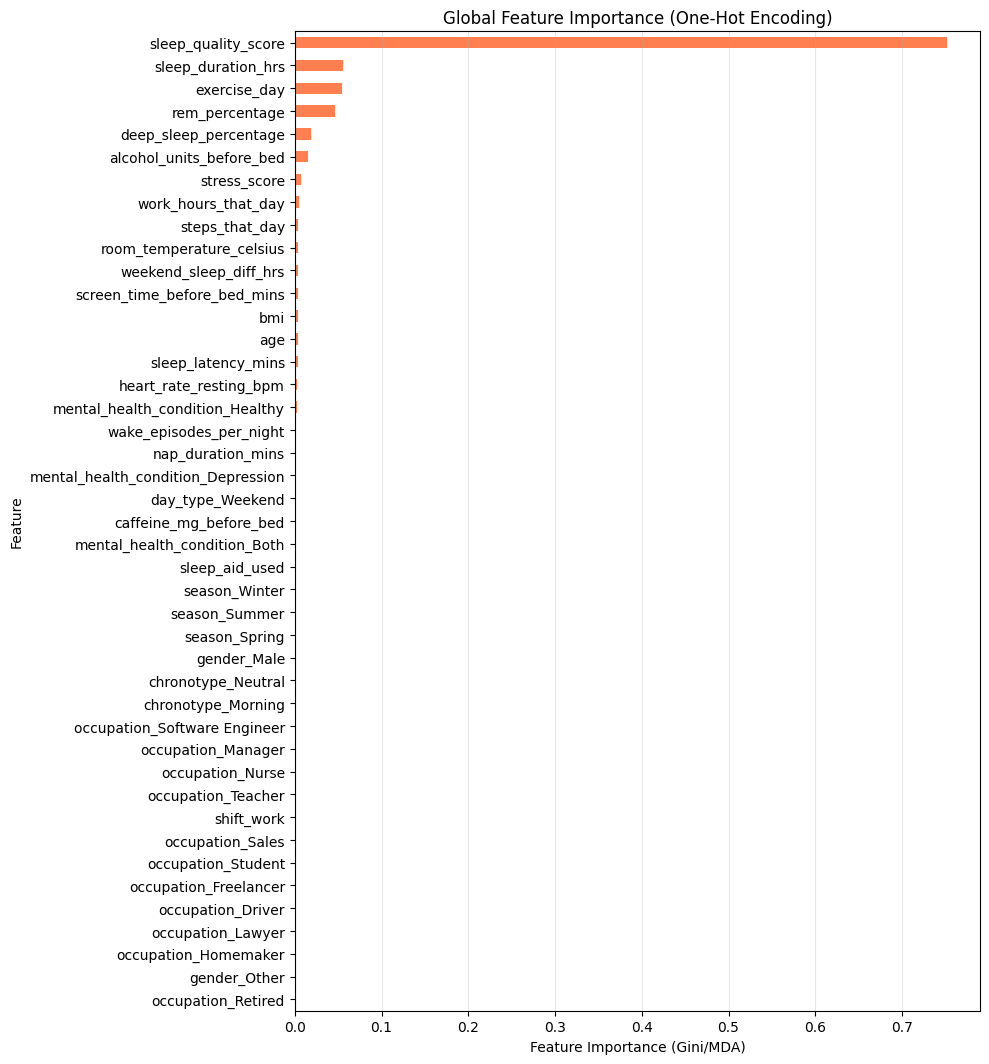

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Извлекаем компоненты из лучшего пайплайна
best_pipeline = gs.best_estimator_
rf_model = best_pipeline.named_steps['rf']
preprocessor = best_pipeline.named_steps['prep']

# 2. Получаем важность и корректные имена признаков ПОСЛЕ трансформации
importances = rf_model.feature_importances_
raw_names = preprocessor.get_feature_names_out()
# Убираем технические префиксы ('cat__', 'num__') для чистого графика
feature_names = [n.split('__', 1)[-1] for n in raw_names]

importance_df = pd.Series(importances, index=feature_names).sort_values(ascending=True)


plt.figure(figsize=(10, max(6, len(feature_names)*0.25)))
importance_df.plot(kind='barh', color='coral')
plt.xlabel("Feature Importance (Gini/MDA)")
plt.ylabel("Feature")
plt.title("Global Feature Importance (One-Hot Encoding)")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## **Задание №4. Интерпретация моделей, основанных на решающих деревьях, в задачах контроля качества**

- Для компании-произвозителя собачьего корма, необходимо попытаться предсказать, почему некоторые партии их корма портятся гораздо быстрее, чем предполагалось.

- К сожалению, эта компания по производству собачьего корма не обновила свое оборудование до последних моделей, что означает, что количество пяти консервантов, которые они используют, может значительно варьироваться. Но какой из консервантов оказывает наибольшее влияние?

- Сначала компания по производству собачьего корма готовит партию консерванта, которая содержит 4 разных консерванта (A, B, C, D), а затем добавляет "наполнитель". Ученые полагают, что один из консервантов A, B, C или D вызывает проблему и необходимо выяснить, какой именно.



Используйте алгоритм случайного леса (Random Forest) для определения важности признаков. На основе полученных результатов установите, какой именно консервант (A, B, C или D) в наибольшей степени влияет на преждевременную порчу партий собачьего корма.

* Pres_A : Процент консерванта A в смеси
* Pres_B : Процент консерванта B в смеси
* Pres_C : Процент консерванта C в смеси
* Pres_D : Процент консерванта D в смеси
* Spoiled: Метка, указывающая, испортилась ли партия собачьего корма.



#### **Загрузка исходные данных (запустите эту ячейку!)**

In [38]:
%%capture
!git clone --recursive https://github.com/tester170/Other.git
!ls Other/
!unzip "/content/Other/data.zip" -d "/content/"

___

#### **Тщательно подумайте о том, что на самом деле требуется решить в этой задаче!**
____

In [39]:
import pandas as pd

data = pd.read_csv('data/dog_food.csv')

In [40]:
data.head()

,A,B,C,D,Spoiled
0,4,2,12.0,3,1.0
1,5,6,12.0,7,1.0
2,6,2,13.0,6,1.0
3,4,2,12.0,1,1.0
4,4,2,12.0,3,1.0


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data.drop('Spoiled', axis=1), data['Spoiled'], test_size = 0.33, random_state = 42)
X_train.shape, X_test.shape

((328, 4), (162, 4))

In [42]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, random_state=42)

In [43]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

max_depth = [int(i) for i in np.linspace(start=1, stop=100, num=10)]
max_depth.append(None)
param_grid = {
    'n_estimators': [int(x) for x in np.linspace(start=100, stop=500, num=10)],
    'max_leaf_nodes': [int(i) for i in np.linspace(start=2, stop=100, num=10)],
    'max_depth': max_depth
}
rf_rcv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=100,
    cv=5,
    random_state=42,
    n_jobs=-1
)

rf_rcv.fit(X_train, y_train)
best_model = rf_rcv.best_estimator_
print(f'Лучшая модель: {best_model}')

Лучшая модель: RandomForestClassifier(max_depth=34, max_leaf_nodes=23, n_estimators=455,
                       random_state=42)


In [44]:
from sklearn.ensemble import RandomForestClassifier

best_model = RandomForestClassifier(max_depth=34, max_leaf_nodes=23, n_estimators=455,
                       random_state=42)
best_model.fit(X_train, y_train)

pred = best_model.predict(X_test) # предсказываем какие партии испортятся
fin = X_test.copy()
fin['Spoiled'] = pred # создаем колонку для результатов предсказания
fin = fin[fin['Spoiled'] != 0] # убираем все хорошие партии
print("Чем больше значение, тем больше влияние консерванта на партию")
for i in fin.columns:
  if i != 'Spoiled':
    print(f'{i}: {fin[i].sum()}')

# fin = {} # в данном варианте был просто вывод влияния на ВСЕ партии - и плохие, и хорошие
# однако и так и так - ответ всё тт же - консервант С
# for i, score in enumerate(best_model.feature_importances_):
#   fin[data.columns[i]] = score
# fin_df = pd.DataFrame.from_dict(fin, orient='index')
# fin_df

Чем больше значение, тем больше влияние консерванта на партию
A: 294
B: 269
C: 615.0
D: 294
